In [535]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import t
import graphviz as gr
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold

## Data

We load the data, convert to metric units, compute the BMI, and drop NA.

In [536]:
df = pd.read_csv("babies.csv")
df = df.dropna()
df["bwt"] = df["bwt"] * 0.0283
df["BMI"] = df["weight"] * 0.4536 / ((df["height"]  * 0.0254) ** 2)
df = df.drop(["case", "weight", "height"], axis=1)
df

,bwt,gestation,parity,age,smoke,BMI
0,3.3960,284.0,0,27.0,0.0,18.290359
1,3.1979,282.0,0,33.0,0.0,23.172849
2,3.6224,279.0,0,28.0,1.0,19.739834
4,3.0564,282.0,0,23.0,1.0,19.577896
5,3.8488,286.0,0,25.0,0.0,17.010034
...,...,...,...,...,...,...
1231,3.1979,275.0,1,27.0,0.0,19.530039
1232,3.6224,265.0,0,24.0,0.0,18.794780
1233,3.6790,291.0,0,30.0,1.0,24.961470
1234,3.5375,281.0,1,21.0,0.0,18.305078


In [537]:
X = ["gestation", "parity", "age", "BMI"]
T = "smoke"
Y = "bwt"

#### Bias

In [538]:
df["smoke"].sum()/len(df)

40% were smoking during pregnancy! We don't know the origins of this dataset. It could be:
- from the 60's (before tobacco harm was strongly established)
- subject to selection bias

Note that the data contains only pregnancies that reach their term. If smoking caused an increase rate of abortion, there would be an obvious incentive to not smoke during pregnancy. Unfortunately, our data can unfortunately tell nothing about this.

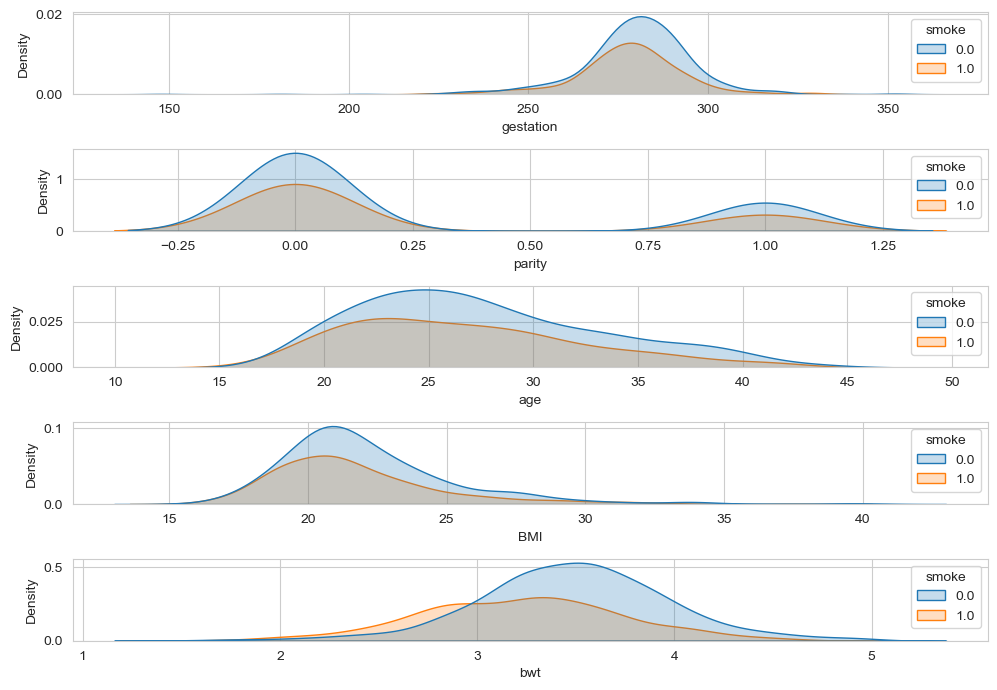

In [539]:
fig, axes = plt.subplots(nrows=len(X) + 1, ncols=1, figsize=(10,7))

for v, ax in zip(X + [Y], axes):
    sns.kdeplot(x=v, hue=T, data=df, ax=ax, fill=True)
    ax.set_xlabel(v)

plt.tight_layout()
plt.show()

From looking at the densities, one cannot identify any obvious selection bias.
We can however see that there is a strong overlap with all the features, so the positivity assumption will hold no matter the admissible set.

## Causal graph

We propose the following causal graph:
- `age` -> `smoke`: older mothers tend to be more educated than younger ones. As a result they may be more aware of harm caused by smoking during pregnancy and adapt their behavior accordingly. Corr: -0.06
- `age` -> `parity`: the older the mother, the less likely this his her first pregnancy. Corr: -0.35
- `age` -> `BMI`: simultaneous decrease in physical activity and lowering of metabolic activity with age leads to higher BMI. Corr: 0.17
- `parity` -> `gestation`: First pregnancies are often associated with slightly longer pregnancies due to changes in uterine and cervical characteristics after prior pregnancies. Some later pregnancies can have higher risks of preterm birth although age is a strong confounder. Corr: 0.08
- `smoke` -> `BMI`: smoking is known to cause weight loss, while quitting smoking has the opposite effect. Corr: -0.07
- `smoke` -> `gestation`: smoking during pregnancy is known to increase the chances of preterm birth.
- `smoke` -> `bwt`: smoking during pregnancy is known to impair fetal growth
- `BMI` -> `gestation`: high body mass during pregnancy may cause shorter gestation due to hormonal activity change and increase the likelihood of induced delivery due to complications (diabetes, hypertension). Corr: -0.01
- `gestion` -> `bwt`: obviously, longer gestation causes higher birth weight since the fetus has more time to develop. Corr: 0.41

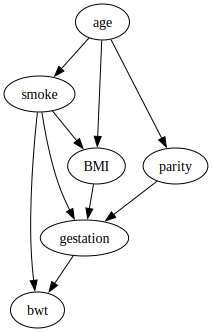

In [540]:
g = gr.Digraph()

g.edge("age", "smoke")
g.edge("age", "BMI")
g.edge("age", "parity")
g.edge("smoke", "gestation")
g.edge("smoke", "BMI")
g.edge("smoke", "bwt")
g.edge("gestation", "bwt")
g.edge("BMI", "gestation")
g.edge("parity", "gestation")
g

In [541]:
df.corr()

,bwt,gestation,parity,age,smoke,BMI
bwt,1.000000,0.407543,-0.043908,0.026983,-0.246800,0.063811
gestation,0.407543,1.000000,0.080916,-0.053425,-0.060267,-0.011891
parity,-0.043908,0.080916,1.000000,-0.351041,-0.009599,-0.129255
age,0.026983,-0.053425,-0.351041,1.000000,-0.067772,0.165408
smoke,-0.246800,-0.060267,-0.009599,-0.067772,1.000000,-0.074903
BMI,0.063811,-0.011891,-0.129255,0.165408,-0.074903,1.000000


### Backdoor criterion

We want to estimate the effect of smoking (`smoke`) on weight at birth (`bwt`). To find the admissible set, we use the backdoor criterion:
- we need to close all paths incoming to the treatment (`smoke`)
- no descendent of `smoke` should be in the set.

Following these rules, we need to observe `age`.

Assumption: Unconfoundedness / ignorability: If `U→{smoke} and U→bwt then P(bwt|smoke,age,U) = P(bwt|smoke,age)`

Although not required, we also include `parity` in the set to improve the influence of age on gestation.

In [542]:
X = ['age', 'parity']

## ATE

### Naive model

Assumptions:
- no bias
- no confounders

In [543]:
treated_mean = df[df[T] == 1][Y].mean()
control_mean = df[df[T] == 0][Y].mean()
print(f"E(bwt|smoke) = {treated_mean}")
print(f"E(bwt|~smoke) = {control_mean}")
print(f"ATE = {treated_mean - control_mean}")

E(bwt|smoke) = 3.2210825708061
E(bwt|~smoke) = 3.483314405594406
ATE = -0.2622318347883059


### Linear model

Assumptions:
- linearity
- no selection bias
- right causal model

In [544]:
model = smf.ols(Y + ' ~ ' + ' + '.join(X + [T]), data=df).fit()
model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,3.5155,0.080,43.672,0.000,3.358,3.673
age,-0.0006,0.003,-0.228,0.820,-0.006,0.005
parity,-0.0574,0.036,-1.611,0.108,-0.127,0.013
smoke,-0.2632,0.030,-8.729,0.000,-0.322,-0.204


ATE = -0.26 (CI: -0.32, -0.20)

### Augmented Inverse-Probability Weighting (AIPW)

Doubly robust estimation using a logistic regression for propensity estimation (as it needs to be calibrated), and a gradient boosting regression for the outcome model.
This gives us one more chance to get a model that is not misspecified.

In [545]:
def AIPW(df):
    ps_score = LogisticRegression(C=1e6, max_iter=1000).fit(df[X], df[T]).predict_proba(df[X])[:, 1]
    model = HistGradientBoostingRegressor(max_depth=None, min_samples_leaf=10, max_leaf_nodes=5)
    #model = LinearRegression()
    model.fit(df[X + [T]], df[Y])
    mu0 = model.predict(df[X].assign(**{T: 0}))
    mu1 = model.predict(df[X].assign(**{T: 1}))

    return np.mean(df[T]*(df[Y] - mu1)/ps_score + mu1) - \
        np.mean((1-df[T])*(df[Y] - mu0)/(1-ps_score) + mu0)

In [546]:
from joblib import Parallel, delayed # for parallel processing

def bootstrap(estimand, df):
    np.random.seed(88)
    # run 1000 bootstrap samples
    bootstrap_sample = 1000
    ates = Parallel(n_jobs=4)(delayed(estimand)(df.sample(frac=1, replace=True))
                              for _ in range(bootstrap_sample))
    ates = np.array(ates)

    sns.displot(ates, kde=False)
    plt.vlines(np.percentile(ates, 2.5), 0, 120, linestyles="dotted")
    plt.vlines(np.percentile(ates, 97.5), 0, 120, linestyles="dotted", label="95% CI")
    plt.title("ATE Bootstrap Distribution")
    plt.legend()

    print(f"ATE mean: {ates.mean()}")
    print(f"ATE 95% CI: ({round(np.percentile(ates, 2.5), 2)}, {round(np.percentile(ates, 97.5), 2)})")

ATE mean: -0.2641371815001431
ATE 95% CI: (-0.32, -0.2)


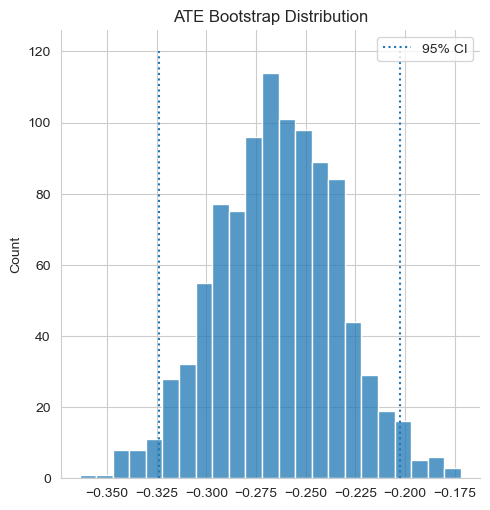

In [547]:
bootstrap(AIPW, df)


There is not much difference with the simpler models. This might be due to the fact that the propensity varies very little. Therefore the one-step correction does not do much.

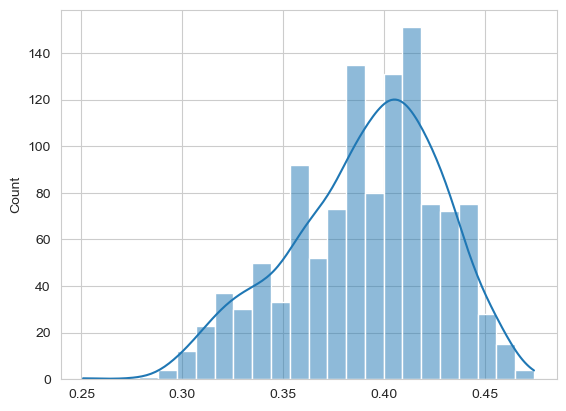

In [548]:
ps_score = LogisticRegression(C=1e6, max_iter=1000).fit(df[X], df[T]).predict_proba(df[X])[:, 1]
sns.histplot(ps_score, kde=True, fill=True);

### Orthogonal and Debiased ML

We use an R-learner: a linear model of the residuals of both the outcome and the treatment. The residuals are obtained via two separate gradient boosting models.
The linear assumption of the residuals is a strong one and may cause misspecification, but since we use non-parametric flexible models to compute the residuals, we should get a reasonable estimation.

In [549]:
np.random.seed(123)
train, test = train_test_split(df, test_size=0.4)
print(train.shape, test.shape)

(704, 6) (470, 6)


In [550]:
debias_m = HistGradientBoostingRegressor(max_depth=None, min_samples_leaf=10, max_leaf_nodes=5)

train_pred_res = train.assign(T_res =  train[T] -
                          cross_val_predict(debias_m, train[X], train[T], cv=5))

denoise_m = HistGradientBoostingRegressor(max_depth=None, min_samples_leaf=10, max_leaf_nodes=5)

train_pred_res = train_pred_res.assign(Y_res =  train[Y] -
                               cross_val_predict(denoise_m, train[X], train[Y], cv=5))

final_model = smf.ols(formula='Y_res ~ T_res', data=train_pred_res).fit()
final_model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-0.0019,0.019,-0.098,0.922,-0.039,0.036
T_res,-0.2286,0.038,-5.978,0.000,-0.304,-0.153


ATE = -0.23 (CI: -0.30, -0.16)

We now perform the same but using cross-fitting to obtain a debiased estimation:

In [551]:
def ci(arr, confidence=0.95):
    sem = np.std(x, ddof=1) / np.sqrt(len(x))  # Standard error
    ci = t.interval(
        confidence=confidence,
        df=len(x) - 1,
        loc=np.mean(arr),
        scale=sem
    )
    return round(float(ci[0]), 2), round(float(ci[1]), 2)

In [552]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

arr = []

for train_idx, test_idx in kf.split(df):
    df_train_k = df.iloc[train_idx]
    df_test_k = df.iloc[test_idx]

    ps_score = LogisticRegression(C=1e6, max_iter=1000).fit(df_train_k[X], df_train_k[T]).predict_proba(df_test_k[X])[:, 1]
    model = HistGradientBoostingRegressor(max_depth=None, min_samples_leaf=10, max_leaf_nodes=5)
    #model = LinearRegression()
    model.fit(df_train_k[X + [T]], df_train_k[Y])
    mu0 = model.predict(df_test_k[X].assign(**{T: 0}))
    mu1 = model.predict(df_test_k[X].assign(**{T: 1}))

    m = np.mean(df_test_k[T]*(df_test_k[Y] - mu1)/ps_score + mu1) - \
        np.mean((1-df_test_k[T])*(df_test_k[Y] - mu0)/(1-ps_score) + mu0)
    arr.append(m)

x = np.asarray(arr)

print(np.mean(x))
print(ci(x))

-0.26791964233393256
(-0.39, -0.14)


## CATE

In [553]:
from toolz import curry

@curry
def elast(data, y, t):
    return (np.sum((data[t] - data[t].mean())*(data[y] - data[y].mean())) /
            np.sum((data[t] - data[t].mean())**2))

def cumulative_gain(dataset, prediction, y, t, min_periods=30, steps=100):
    size = dataset.shape[0]
    ordered_df = dataset.sort_values(prediction, ascending=False).reset_index(drop=True)
    n_rows = list(range(min_periods, size, size // steps)) + [size]
    return np.array([elast(ordered_df.head(rows), y, t) * (rows/size) for rows in n_rows])

In [554]:
def analyze(train_pred, test_pred):
    sns.kdeplot(x="CATE", data=test_pred, fill=True)
    plt.show()
    print(test_pred["CATE"].mean())

    sns.scatterplot(data=test_pred, x="age", y="CATE", hue="parity")
    plt.show()

    gain_curve_test = cumulative_gain(test_pred, "CATE", y=Y, t=T)
    gain_curve_train = cumulative_gain(train_pred, "CATE", y=Y, t=T)
    plt.plot(gain_curve_test, color="C0", label="Test")
    plt.plot(gain_curve_train, color="C1", label="Train")
    plt.plot([0, 100], [0, elast(test, Y, T)], linestyle="--", color="black", label="Baseline")
    plt.legend()
    plt.show()


    # Create decade bins (e.g. 20-29, 30-39, ...)
    test_pred["decade"] = ((test_pred["age"] // 10) * 10).astype(int)

    summary = (
    test_pred.groupby(["decade", "parity"])["CATE"]
      .agg(mean="mean", std="std", n="count")
      .reset_index()
    )

    summary["sem"] = summary["std"] / np.sqrt(summary["n"])
    summary["ci95"] = summary.apply(
        lambda r: t.ppf(0.975, r["n"] - 1) * r["sem"] if r["n"] > 1 else np.nan,
        axis=1,
    )

    # Plot
    plt.figure(figsize=(7, 5))

    for parity, grp in summary.groupby("parity"):
        grp = grp.sort_values("decade")
        plt.plot(
            grp["decade"],
            grp["mean"],
            marker="o",
            label=parity,
        )

        plt.fill_between(
            grp["decade"],
            grp["mean"] - grp["ci95"],
            grp["mean"] + grp["ci95"],
            alpha=0.2,
        )

    plt.xticks(
        sorted(summary["decade"].unique()),
        [f"{d}s" for d in sorted(summary["decade"].unique())]
    )

    plt.xticks(summary["decade"], [f"{d}s" for d in summary["decade"]])
    plt.xlabel("Age decade")
    plt.ylabel("CATE")
    plt.title("CATE by age decade (95% CI)")
    plt.legend(title="Parity")
    plt.grid(alpha=0.3)
    plt.show()

### Plugin estimators

#### S-learner

- Advantage: Uses all observations to learn one outcome model.
- Disadvantages:
  - Treats A like any other “feature”, and may underuse it.
  - May shrink treatment effects toward zero.

In [558]:
np.random.seed(123)
s_learner = HistGradientBoostingRegressor(max_depth=None, min_samples_leaf=10, max_leaf_nodes=5)
#s_learner = Pipeline([
#    ("poly", PolynomialFeatures(degree=5, include_bias=False)),
#    ("regressor", Ridge(alpha=1.0))
#])
s_learner.fit(train[X+[T]], train[Y]);

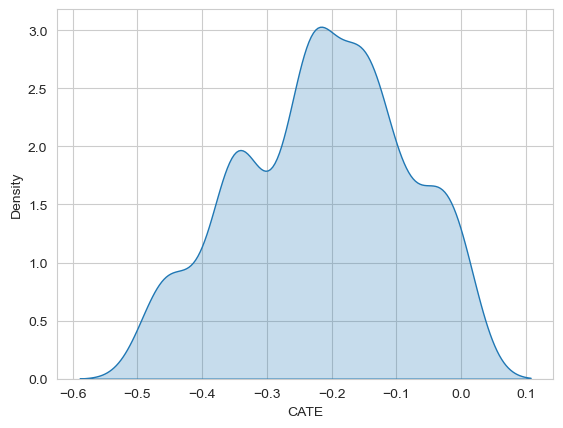

-0.2135167621905826


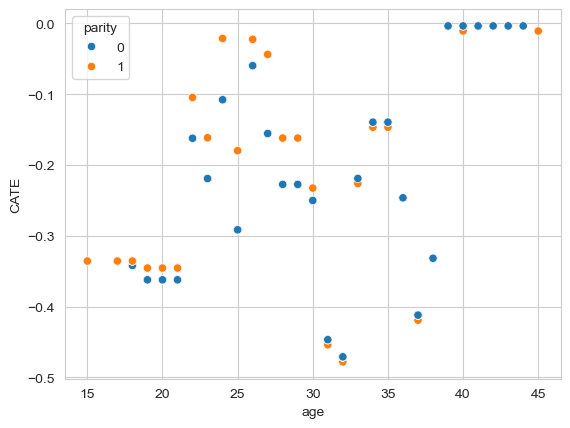

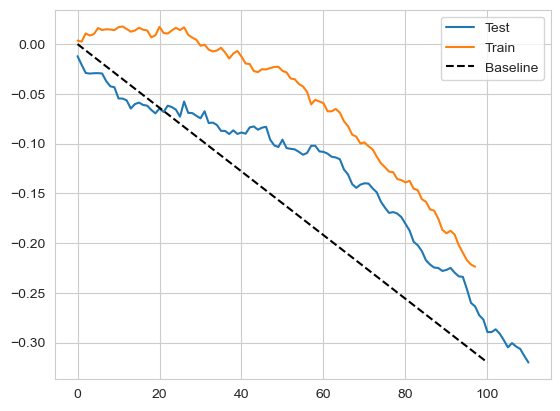

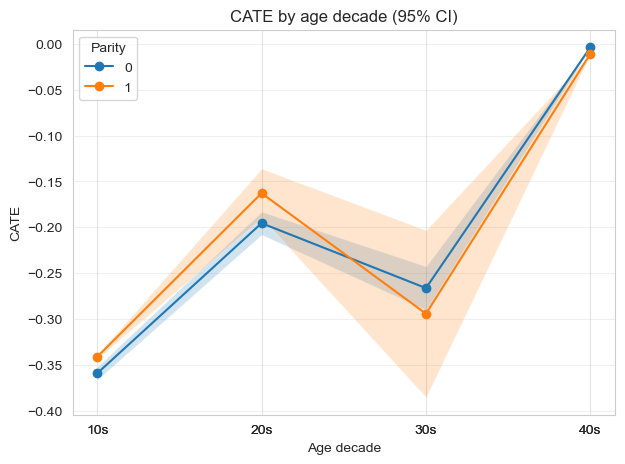

In [559]:
train_pred = train.assign(
    CATE=(s_learner.predict(train[X].assign(**{T: 1})) -
                        s_learner.predict(train[X].assign(**{T: 0}))))

test_pred = test.assign(
    CATE=(s_learner.predict(test[X].assign(**{T: 1})) - # predict under treatment
          s_learner.predict(test[X].assign(**{T: 0}))) # predict under control
)

analyze(train_pred, test_pred)

#### T-learner

- Advantages:
  - Allows different outcome models by treatment arm.
  - More flexible for heterogeneous effects.
- Disadvantages: Each model uses only part of the data.

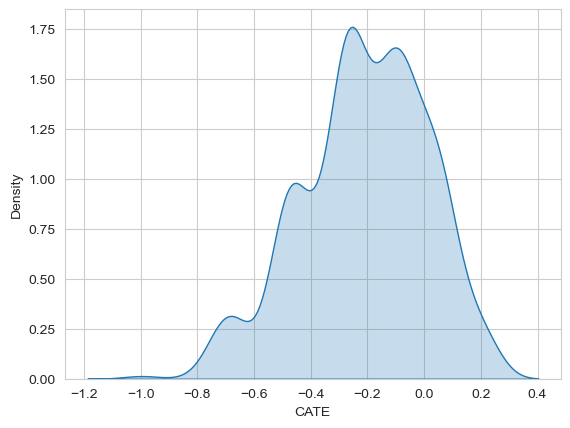

-0.2095829998181579


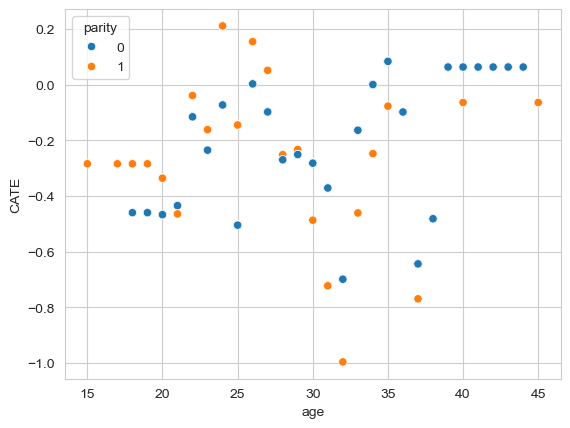

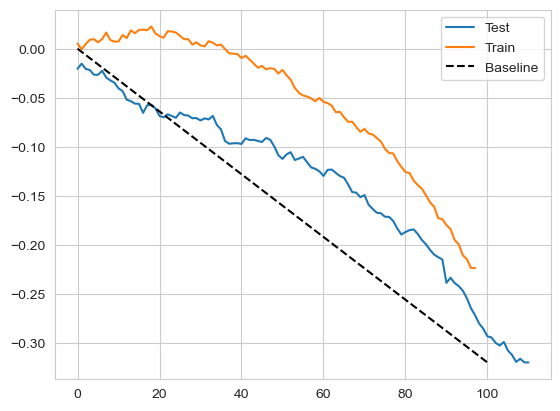

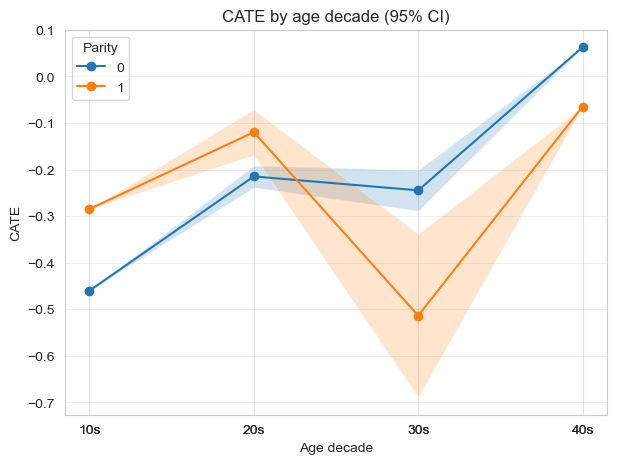

In [560]:
m0 = HistGradientBoostingRegressor(max_depth=None, min_samples_leaf=10, max_leaf_nodes=5)
#m0 = Pipeline([
#    ("poly", PolynomialFeatures(degree=5, include_bias=False)),
#    ("regressor", Ridge(alpha=1.0))
#])
m0.fit(train[X+[T]], train[Y])

m1 = HistGradientBoostingRegressor(max_depth=None, min_samples_leaf=10, max_leaf_nodes=5)
#m1 = Pipeline([
#    ("poly", PolynomialFeatures(degree=5, include_bias=False)),
#    ("regressor", Ridge(alpha=1.0))
#])
m1.fit(train[X+[T]], train[Y])

train_0 = train[train[T] == 0]
train_1 = train[train[T] == 1]
m0.fit(train_0[X], train_0[Y])
m1.fit(train_1[X], train_1[Y])

# estimate the CATE
train_pred = train.assign(CATE=m1.predict(train[X]) - m0.predict(train[X]))
test_pred = test.assign(CATE=m1.predict(test[X]) - m0.predict(test[X]))

analyze(train_pred, test_pred)

#### X-learner

In [561]:
# first stage models
m0 = HistGradientBoostingRegressor(max_depth=None, min_samples_leaf=10, max_leaf_nodes=5)
#m0 = Pipeline([
#    ("poly", PolynomialFeatures(degree=5, include_bias=False)),
#    ("regressor", Ridge(alpha=1.0))
#])
m1 = HistGradientBoostingRegressor(max_depth=None, min_samples_leaf=10, max_leaf_nodes=5)
#m1 = Pipeline([
#    ("poly", PolynomialFeatures(degree=5, include_bias=False)),
#    ("regressor", Ridge(alpha=1.0))
#])

# propensity score model
g = LogisticRegression(solver="lbfgs", penalty='l2')

m0.fit(train.query(f"{T}==0")[X], train.query(f"{T}==0")[Y])
m1.fit(train.query(f"{T}==1")[X], train.query(f"{T}==1")[Y])

g.fit(train[X], train[T]);

In [562]:
d_train = np.where(train[T]==0,
                   m1.predict(train[X]) - train[Y],
                   train[Y] - m0.predict(train[X]))

# second stage
mx0 = HistGradientBoostingRegressor(max_depth=None, min_samples_leaf=10, max_leaf_nodes=5)
#mx0 = Pipeline([
#    ("poly", PolynomialFeatures(degree=5, include_bias=False)),
#    ("regressor", Ridge(alpha=1.0))
#])
mx1 = HistGradientBoostingRegressor(max_depth=None, min_samples_leaf=10, max_leaf_nodes=5)
#mx1 = Pipeline([
#    ("poly", PolynomialFeatures(degree=5, include_bias=False)),
#    ("regressor", Ridge(alpha=1.0))
#])

mx0.fit(train.query(f"{T}==0")[X], d_train[train[T]==0])
mx1.fit(train.query(f"{T}==1")[X], d_train[train[T]==1]);

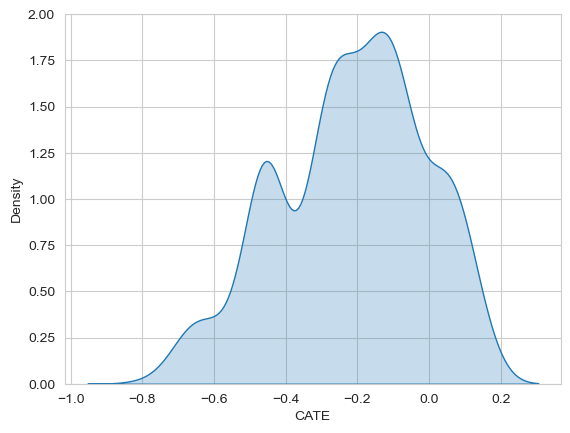

-0.2157157883595275


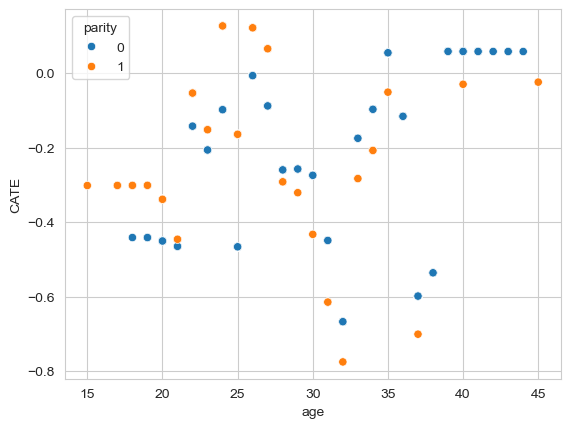

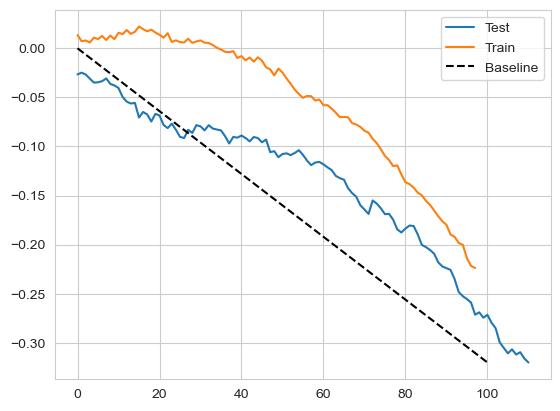

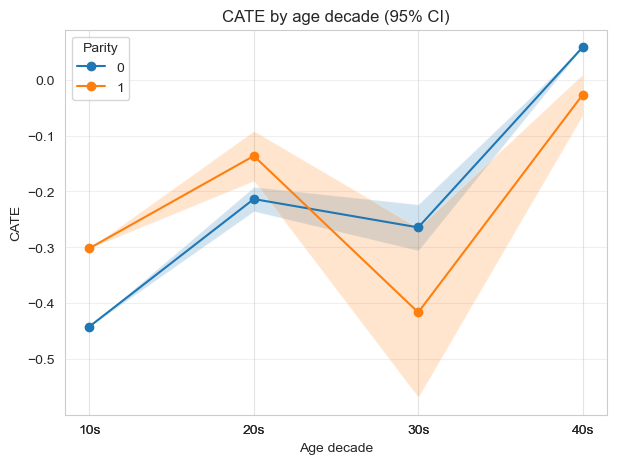

In [563]:
def ps_predict(df, t):
    return g.predict_proba(df[X])[:, t]


train_pred = train.assign(CATE=(ps_predict(train,1)*mx0.predict(train[X]) +
                ps_predict(train,0)*mx1.predict(train[X])))

test_pred = test.assign(CATE=(ps_predict(test,1)*mx0.predict(test[X]) +
                                ps_predict(test,0)*mx1.predict(test[X])))

analyze(train_pred, test_pred)

### Debiased ML

#### R learner

Linear R-learner (Robinson residualization). Can work fine since we have good overlap.
- Advantage: Orthogonal to first-order nuisance error.
- Drawback: Not doubly robust

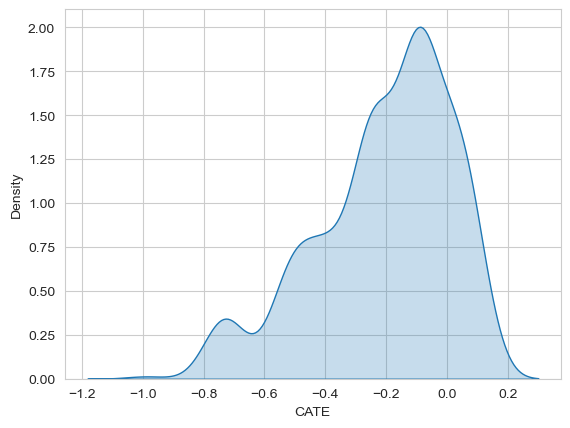

-0.20858447219978857


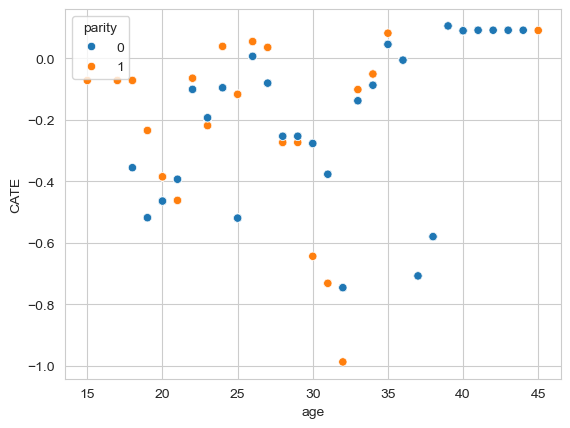

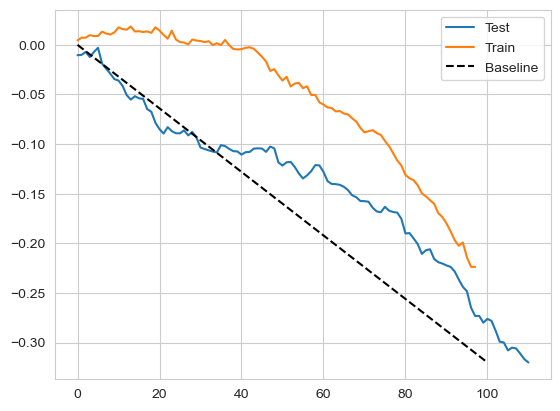

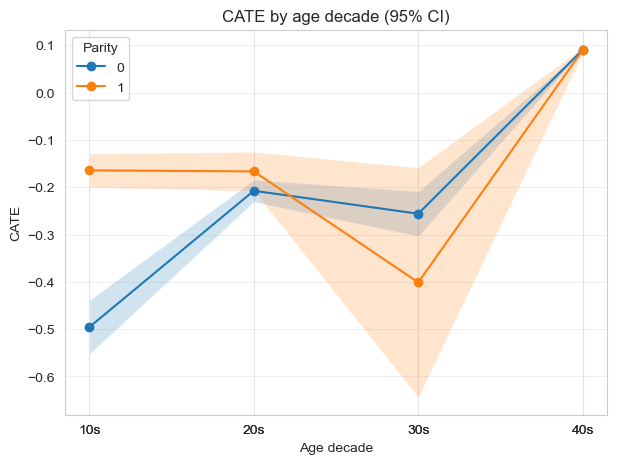

In [564]:
final_model_cate = smf.ols(formula='Y_res ~ T_res * (age + parity)', data=train_pred_res).fit()

debias_m = HistGradientBoostingRegressor(max_depth=None, min_samples_leaf=10, max_leaf_nodes=5)
debias_m.fit(train[X], train[Y])

test_pred_res = test.assign(T_res =  test[T] -
                          debias_m.predict(test[X])
                          + test[T].mean()) # add mu_t for visualization.

denoise_m = HistGradientBoostingRegressor(max_depth=None, min_samples_leaf=10, max_leaf_nodes=5)
denoise_m.fit(train[X], train[Y])

test_pred_res = test_pred_res.assign(Y_res =  test[Y] -
                               denoise_m.predict(test[X])
                               + test[Y].mean())

model_final = HistGradientBoostingRegressor(max_depth=None, min_samples_leaf=10, max_leaf_nodes=5)

# create the weights
w = train_pred_res["T_res"] ** 2

# create the transformed target
y_star = (train_pred_res["Y_res"] / train_pred_res["T_res"])

# use a weighted regression ML model to predict the target with the weights.
model_final.fit(X=train[X], y=y_star, sample_weight=w)

train_pred = train.assign(CATE=model_final.predict(train[X]))
test_pred = test.assign(CATE=model_final.predict(test[X]))
analyze(train_pred, test_pred)